Image directory exists: True
Annotation directory exists: True
Found 3534 images
Found 10474 annotations
Total Images: 3534
Total Annotations: 10474


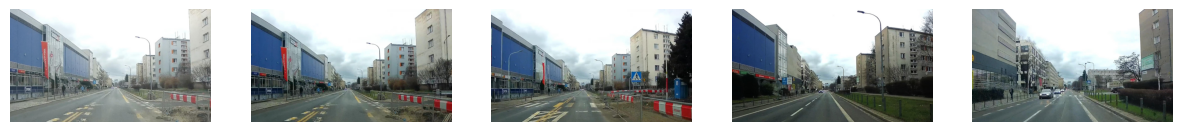

KeyboardInterrupt: 

In [ ]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import seaborn as sns
import numpy as np
from PIL import Image
#Definirea cailor
train_image_dir = r'./drive/MyDrive/SBC/road_detection/road_detection/train/images'
train_annotation_dir = r'./drive/MyDrive/SBC/road_detection/road_detection/train/labels'

val_image_dir = r'./drive/MyDrive/SBC/road_detection/road_detection/valid/images'
val_annotation_dir = r'./drive/MyDrive/SBC/road_detection/road_detection/valid/labels'
#Definirea claselor
classes = ["Car", "Different-Traffic-Sign", "Green-Traffic-Light", "Motorcycle",
           "Pedestrian", "Pedestrian-Crossing", "Prohibition-Sign",
           "Red-Traffic-Light", "Speed-Limit-Sign", "Truck", "Warning-Sign"]

print(f"Image directory exists: {os.path.exists(train_image_dir)}")
print(f"Annotation directory exists: {os.path.exists(train_annotation_dir)}")
#Colectarea fisierelor
train_image_paths = glob(os.path.join(train_image_dir, '*.jpg'))
train_annotation_paths = glob(os.path.join(train_annotation_dir, '*.txt'))

val_image_paths = glob(os.path.join(val_image_dir, '*.jpg'))
val_annotation_paths = glob(os.path.join(val_annotation_dir, '*.txt'))

print(f"Found {len(train_image_paths)} images")
print(f"Found {len(train_annotation_paths)} annotations")
#Verificam daca avem imagini sau nu
if len(train_image_paths) == 0 or len(train_annotation_paths) == 0:
    print("ERROR: No images or annotations found! Please check your paths.")
    print(f"Image directory: {train_image_dir}")
    print(f"Annotation directory: {train_annotation_dir}")

    if os.path.exists(train_image_dir):
        print(f"Files in image directory: {os.listdir(image_dir)[:5]}")  # First 5 files
    if os.path.exists(train_annotation_dir):
        print(f"Files in annotation directory: {os.listdir(train_annotation_dir)[:5]}")
else:
    print(f"Total Images: {len(train_image_paths)}")
    print(f"Total Annotations: {len(train_annotation_paths)}")
#Functie vizualizare, afisam primele n imagini
    def visualize_sample_images(image_paths, n=5):
        plt.figure(figsize=(15, 10))
        for i, img_path in enumerate(image_paths[:n]):
            img = Image.open(img_path)
            plt.subplot(1, n, i + 1)
            plt.imshow(img)
            plt.axis('off')
        plt.show()

    visualize_sample_images(train_image_paths)
#Analiza distributiei, se citesc toate fisierele
    def get_class_distribution(annotation_paths, classes):
        class_counts = {cls: 0 for cls in classes}
        for annotation_path in annotation_paths:
            with open(annotation_path, 'r') as file:
                lines = file.readlines()
                for line in lines:
                    class_id = int(line.split()[0])
                    class_name = classes[class_id]
                    class_counts[class_name] += 1
        return class_counts

    class_distribution = get_class_distribution(train_annotation_paths, classes)
    class_df = pd.DataFrame(list(class_distribution.items()), columns=['Class', 'Count'])

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Class', y='Count', data=class_df)
    plt.xticks(rotation=90)
    plt.title("Class Distribution in Dataset")
    plt.show()
#Preprocesarea imaginilor, le aduce la 640x640, standard yolo
    def preprocess_images(image_paths, target_size=(640, 640)):
        processed_images = []
        for img_path in image_paths:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, target_size)
                processed_images.append(img)
            else:
                print(f"Warning: Could not read image {img_path}")
        return processed_images

    processed_images = preprocess_images(train_image_paths[:5])
    if processed_images:
        plt.figure(figsize=(15, 10))
        for i, img in enumerate(processed_images):
            plt.subplot(1, 5, i + 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        plt.show()
#Augmentare, simulam conditii diferite de lumina
    def augment_brightness(image, factor=1.5):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        hsv = np.array(hsv, dtype=np.float64)
        hsv[:, :, 2] = hsv[:, :, 2] * factor
        hsv[:, :, 2][hsv[:, :, 2] > 255] = 255
        hsv = np.array(hsv, dtype=np.uint8)
        img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
        return img

    if processed_images:
        augmented_images = [augment_brightness(img, factor=1.2) for img in processed_images]

        plt.figure(figsize=(15, 10))
        for i, img in enumerate(augmented_images):
            plt.subplot(1, 5, i + 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        plt.show()
#Citire coordonate
    def load_yolo_annotations(file_path):
        boxes = []
        try:
            with open(file_path, 'r') as file:
                lines = file.readlines()
                for line in lines:
                    class_id, x_center, y_center, width, height = map(float, line.strip().split())
                    boxes.append((class_id, x_center, y_center, width, height))
        except Exception as e:
            print(f"Error reading annotation file {file_path}: {e}")
        return boxes
#Verificare vizuala
    def plot_boxes(img_path, annotation_path):
        img = cv2.imread(img_path)
        if img is None:
            print(f"Error: Could not read image {img_path}")
            return

        h, w, _ = img.shape
        boxes = load_yolo_annotations(annotation_path)

        for box in boxes:
            class_id, x_center, y_center, box_width, box_height = box
            x1 = int((x_center - box_width / 2) * w)
            y1 = int((y_center - box_height / 2) * h)
            x2 = int((x_center + box_width / 2) * w)
            y2 = int((y_center + box_height / 2) * h)

            class_name = classes[int(class_id)]
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

    if len(train_image_paths) > 0 and len(train_annotation_paths) > 0:
        plot_boxes(train_image_paths[0], train_annotation_paths[0])
    else:
        print("Cannot plot boxes: No images or annotations available")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import glob
#Definire clasa RoadDataSet
class RoadDataset(Dataset):
    def __init__(self, img_dir, label_dir, classes, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.classes = classes

        self.img_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
#Lungime dataset
    def __len__(self):
        return len(self.img_files)
#Extragerea unui singur element
    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        image = Image.open(img_path).convert("RGB")

        basename = os.path.basename(img_path)
        label_name = os.path.splitext(basename)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    data = line.strip().split()

                    class_id = int(data[0])

                    bbox = [float(x) for x in data[1:]]

                    labels.append(class_id)
                    boxes.append(bbox)

        target = {}
        target["boxes"] = torch.tensor(boxes)
        target["labels"] = torch.tensor(labels, dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, target

In [ ]:
from torchvision import transforms
#Definire clase
classes = ["Car", "Different-Traffic-Sign", "Green-Traffic-Light", "Motorcycle",
           "Pedestrian", "Pedestrian-Crossing", "Prohibition-Sign",
           "Red-Traffic-Light", "Speed-Limit-Sign", "Truck", "Warning-Sign"]
#Preprocesare, resizeing
transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
])

train_dataset = RoadDataset(
    img_dir=r'./drive/MyDrive/SBC/road_detection/road_detection/train/images',
    label_dir=r'./drive/MyDrive/SBC/road_detection/road_detection/train/labels',
    classes=classes,
    transform=transform
)

val_dataset = RoadDataset(
    img_dir=r'./drive/MyDrive/SBC/road_detection/road_detection/valid/images',
    label_dir=r'./drive/MyDrive/SBC/road_detection/road_detection/valid/labels',
    classes=classes,
    transform=transform
)
#Functia collate_fn,separa imaginile de target-uri
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn # foarte important pentru object detection
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
#Extragerea unui singur lot,verificarea marimii,a dimensiunii si etichetele
images, targets = next(iter(train_loader))

print(f"Batch size: {len(images)}")
print(f"Image shape: {images[0].shape}") #[3, 416, 416]
print(f"First image annotations: {targets[0]}")

Batch size: 16
Image shape: torch.Size([3, 416, 416])
First image annotations: {'boxes': tensor([[0.1081, 0.8029, 0.2109, 0.3411],
        [0.2986, 0.7632, 0.1285, 0.2188],
        [0.3772, 0.7407, 0.0495, 0.1008],
        [0.4818, 0.8318, 0.1545, 0.3132],
        [0.5829, 0.7471, 0.0564, 0.1094],
        [0.6658, 0.7954, 0.1285, 0.2102],
        [0.6950, 0.6557, 0.0133, 0.0644],
        [0.7059, 0.6492, 0.0085, 0.0225],
        [0.5794, 0.6710, 0.0094, 0.0241],
        [0.7159, 0.6814, 0.0075, 0.0225],
        [0.4492, 0.5185, 0.0192, 0.0282],
        [0.5000, 0.5322, 0.0160, 0.0282],
        [0.5523, 0.5499, 0.0163, 0.0266],
        [0.5801, 0.6428, 0.0133, 0.0290],
        [0.7165, 0.6561, 0.0107, 0.0201],
        [0.3613, 0.6211, 0.0140, 0.0611],
        [0.4341, 0.5153, 0.0137, 0.0571],
        [0.4865, 0.5285, 0.0130, 0.0547],
        [0.5386, 0.5462, 0.0124, 0.0467],
        [0.5884, 0.6557, 0.0091, 0.0451]]), 'labels': tensor([ 0,  0,  0,  0,  0,  0,  2,  1,  1,  1,  1,  1,  1,

In [ ]:
import torch
import torch.nn as nn

class SimpleYOLO(nn.Module):
    def __init__(self, num_classes=11):
        super(SimpleYOLO, self).__init__()

        self.num_classes = num_classes
        self.S = 13 # Grid dim
        self.B = 2  # Boxes pe celula

        self.final_depth = (self.B * 5) + self.num_classes

        # Backbone, extragerea trasaturilor vizuale
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Bloc 2
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Bloc 3
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Bloc 4
            nn.Conv2d(128, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Bloc 5
            nn.Conv2d(256, 512, 3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
        )

        # Head,interpretarea trasaturilor extrase si face predictia finala
        self.detector = nn.Sequential(
            nn.Conv2d(512, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Layer-ul final
            nn.Conv2d(1024, self.final_depth, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.detector(x)

        x = x.permute(0, 2, 3, 1)

        return x


model = SimpleYOLO(num_classes=11)
dummy_input = torch.randn(1, 3, 416, 416)
output = model(dummy_input)
print(f"Output Shape: {output.shape}")
#torch.Size asteptat =([1, 13, 13, 21])

Output Shape: torch.Size([1, 13, 13, 21])


In [ ]:
import torch
import torch.nn as nn
#Functie de conversie coordonate, afltam x_min,y_min,x_max,y_max
def xywh_to_xyxy(xywh: torch.Tensor) -> torch.Tensor:
    """
    xywh: (..., 4) with center x,y and width,height (all normalized 0-1 in image space)
    returns: (..., 4) in xyxy
    """
    x, y, w, h = xywh[..., 0], xywh[..., 1], xywh[..., 2], xywh[..., 3]
    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2
    return torch.stack([x1, y1, x2, y2], dim=-1)
#Calcul iou, masoara suprapunerea dreptughiurilor
def iou_xyxy(box1: torch.Tensor, box2: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """
    box1, box2: (..., 4) in xyxy
    returns: (...) IoU
    """
    x1 = torch.max(box1[..., 0], box2[..., 0])
    y1 = torch.max(box1[..., 1], box2[..., 1])
    x2 = torch.min(box1[..., 2], box2[..., 2])
    y2 = torch.min(box1[..., 3], box2[..., 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (box1[..., 2] - box1[..., 0]).clamp(min=0) * (box1[..., 3] - box1[..., 1]).clamp(min=0)
    area2 = (box2[..., 2] - box2[..., 0]).clamp(min=0) * (box2[..., 3] - box2[..., 1]).clamp(min=0)
    return inter / (area1 + area2 - inter + eps)
#Clasa loss
class YoloLoss(nn.Module):
    def __init__(self, S: int = 13, B: int = 2, C: int = 11):
        super().__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5.0

    def forward(self, predictions: torch.Tensor, target: list[dict]) -> torch.Tensor:
        """
        predictions: (B, S, S, 5*B + C) with B=2, C=11 => 21
        target: list of dicts, each with:
            boxes: (N, 4) in YOLO format [x, y, w, h] normalized 0-1
            labels: (N,)
        """
        batch_size = predictions.shape[0]
        device = predictions.device

        target_tensor = torch.zeros_like(predictions)
        exists_box = torch.zeros((batch_size, self.S, self.S, 1), device=device)

        for b in range(batch_size):
            boxes = target[b]["boxes"]
            labels = target[b]["labels"]

            for box, label in zip(boxes, labels):
                x, y, w, h = box

                i_cell = int(self.S * y)
                j_cell = int(self.S * x)

                i_cell = min(max(i_cell, 0), self.S - 1)
                j_cell = min(max(j_cell, 0), self.S - 1)

                x_cell = (self.S * x) - j_cell
                y_cell = (self.S * y) - i_cell

                if exists_box[b, i_cell, j_cell, 0] == 0:
                    target_tensor[b, i_cell, j_cell, 0:5] = torch.tensor([x_cell, y_cell, w, h, 1.0], device=device)
                    target_tensor[b, i_cell, j_cell, 5:10] = torch.tensor([x_cell, y_cell, w, h, 1.0], device=device)

                    target_tensor[b, i_cell, j_cell, 10 + int(label)] = 1.0
                    exists_box[b, i_cell, j_cell, 0] = 1.0
        #Calcul loss
        pred_box1 = predictions[..., 0:4]
        pred_conf1 = predictions[..., 4:5]

        pred_box2 = predictions[..., 5:9]
        pred_conf2 = predictions[..., 9:10]

        tgt_box = target_tensor[..., 0:4]

        S = self.S
        grid_y = torch.arange(S, device=device).view(1, S, 1, 1).expand(batch_size, S, S, 1)
        grid_x = torch.arange(S, device=device).view(1, 1, S, 1).expand(batch_size, S, S, 1)

        p1_xy = torch.cat([(grid_x + pred_box1[..., 0:1]) / S,
                           (grid_y + pred_box1[..., 1:2]) / S], dim=-1)
        p2_xy = torch.cat([(grid_x + pred_box2[..., 0:1]) / S,
                           (grid_y + pred_box2[..., 1:2]) / S], dim=-1)
        t_xy = torch.cat([(grid_x + tgt_box[..., 0:1]) / S,
                          (grid_y + tgt_box[..., 1:2]) / S], dim=-1)

        p1_wh = pred_box1[..., 2:4].abs()
        p2_wh = pred_box2[..., 2:4].abs()
        t_wh = tgt_box[..., 2:4]

        p1_abs = torch.cat([p1_xy, p1_wh], dim=-1)
        p2_abs = torch.cat([p2_xy, p2_wh], dim=-1)
        t_abs = torch.cat([t_xy, t_wh], dim=-1)

        iou1 = iou_xyxy(xywh_to_xyxy(p1_abs), xywh_to_xyxy(t_abs)).unsqueeze(-1)
        iou2 = iou_xyxy(xywh_to_xyxy(p2_abs), xywh_to_xyxy(t_abs)).unsqueeze(-1)

        best_box = (iou2 > iou1).float()

        obj_mask = exists_box
        box1_resp = obj_mask * (1 - best_box)
        box2_resp = obj_mask * best_box

        pred1_xy = pred_box1[..., 0:2]
        pred2_xy = pred_box2[..., 0:2]
        tgt_xy2 = tgt_box[..., 0:2]
#Cordonate loss
        pred1_wh_sqrt = torch.sign(pred_box1[..., 2:4]) * torch.sqrt(torch.abs(pred_box1[..., 2:4]) + 1e-6)
        pred2_wh_sqrt = torch.sign(pred_box2[..., 2:4]) * torch.sqrt(torch.abs(pred_box2[..., 2:4]) + 1e-6)
        tgt_wh_sqrt = torch.sqrt(torch.abs(tgt_box[..., 2:4]) + 1e-6)

        pred1_sqrt = torch.cat([pred1_xy, pred1_wh_sqrt], dim=-1)
        pred2_sqrt = torch.cat([pred2_xy, pred2_wh_sqrt], dim=-1)
        tgt_sqrt = torch.cat([tgt_xy2, tgt_wh_sqrt], dim=-1)

        coord_loss = (
            self.mse(torch.flatten(box1_resp * pred1_sqrt, end_dim=-2),
                     torch.flatten(box1_resp * tgt_sqrt,  end_dim=-2))
            +
            self.mse(torch.flatten(box2_resp * pred2_sqrt, end_dim=-2),
                     torch.flatten(box2_resp * tgt_sqrt,  end_dim=-2))
        )
#Object loss
        obj_loss = (
            self.mse(torch.flatten(box1_resp * pred_conf1),
                     torch.flatten(box1_resp * obj_mask))
            +
            self.mse(torch.flatten(box2_resp * pred_conf2),
                     torch.flatten(box2_resp * obj_mask))
        )
#Noobject loss
        noobj_mask1 = (1 - obj_mask) + box2_resp
        noobj_mask2 = (1 - obj_mask) + box1_resp

        noobj_loss = (
            self.mse(torch.flatten(noobj_mask1 * pred_conf1),
                     torch.flatten(noobj_mask1 * torch.zeros_like(pred_conf1)))
            +
            self.mse(torch.flatten(noobj_mask2 * pred_conf2),
                     torch.flatten(noobj_mask2 * torch.zeros_like(pred_conf2)))
        )
#Class loss
        pred_class = predictions[..., 10:]
        tgt_class = target_tensor[..., 10:]

        class_loss = self.mse(
            torch.flatten(obj_mask * pred_class, end_dim=-2),
            torch.flatten(obj_mask * tgt_class,  end_dim=-2)
        )
#Facem media ponderata a erorilor
        loss = (
            self.lambda_coord * coord_loss
            + obj_loss
            + self.lambda_noobj * noobj_loss
            + class_loss
        )
        return loss


Epoch [1/100] [Train]: 100%|██████████| 221/221 [02:49<00:00,  1.30it/s, loss=16.9]


--> Train Loss: 24.3977 | Val Loss: 17.1001


Epoch [2/100] [Train]: 100%|██████████| 221/221 [02:50<00:00,  1.29it/s, loss=14.5]


--> Train Loss: 16.3781 | Val Loss: 16.1326


Epoch [3/100] [Train]: 100%|██████████| 221/221 [02:50<00:00,  1.30it/s, loss=12.4]


...

--> Train Loss: 2.8925 | Val Loss: 10.9224


Epoch [99/100] [Train]: 100%|██████████| 221/221 [02:34<00:00,  1.43it/s, loss=3.13]


--> Train Loss: 2.8592 | Val Loss: 10.6522


Epoch [100/100] [Train]: 100%|██████████| 221/221 [02:35<00:00,  1.42it/s, loss=2.68]


--> Train Loss: 2.8941 | Val Loss: 10.8512


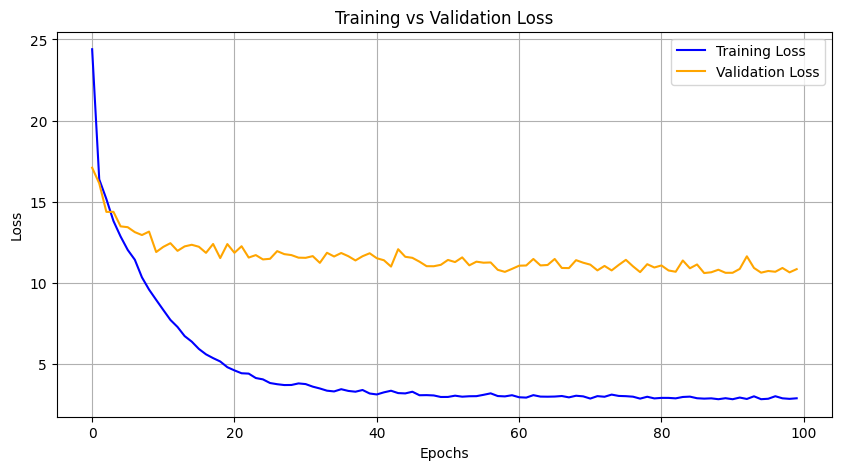

Training Complete.


In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from tqdm import tqdm

os.makedirs("checkpoints", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleYOLO(num_classes=11).to(device)
criterion = YoloLoss(S=13, B=2, C=11)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_loss_history = []
val_loss_history = []

num_epochs = 100

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] [Train]", leave=True)

    for images, targets in loop:
        images = torch.stack(images).to(device)

        for t in targets:
            t["boxes"] = t["boxes"].to(device)
            t["labels"] = t["labels"].to(device)

        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, targets) / images.size(0)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = running_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    val_viz_images = None
    val_viz_targets = None
    val_viz_out = None

    with torch.no_grad():
        for i, (images, targets) in enumerate(val_loader):
            images = torch.stack(images).to(device)

            for t in targets:
                t["boxes"] = t["boxes"].to(device)
                t["labels"] = t["labels"].to(device)

            out = model(images)
            loss = criterion(out, targets) / images.size(0)

            running_val_loss += loss.item()

            if i == 0:
                val_viz_images = images
                val_viz_targets = targets
                val_viz_out = out

    avg_val_loss = running_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    print(f"--> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if (epoch + 1) % 10 == 0:

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss
        }, f"checkpoints/yolo_epoch_{epoch+1}.pth")

plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Training Loss', color='blue')
plt.plot(val_loss_history, label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_graph.png')
plt.show()

print("Training Complete.")

In [ ]:
from PIL import Image
from torchvision import transforms
from torchvision.ops import nms #non maax supresion
import torch

IMAGE_SIZE = 416

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
#Decodare, transformare iesirii in coordonate brute
def yolov1_decode(output, image_size=416, conf_thresh=0.1):
    """
    output: [1, 13, 13, 21] where 21 = 5*B + C (B=2, C=11)
    layout per cell:
      [x1,y1,w1,h1,c1, x2,y2,w2,h2,c2, class0..class10]
    """
    output = output.squeeze(0).detach().cpu()  # [13,13,21]
    S = 13
    boxes, classes, scores = [], [], []

    for i in range(S):
        for j in range(S):
            cell = output[i, j]

            b1 = cell[0:5]
            b2 = cell[5:10]

            if b1[4] >= b2[4]:
                x, y, w, h, conf = b1
            else:
                x, y, w, h, conf = b2

            x = torch.sigmoid(x)
            y = torch.sigmoid(y)
            conf = torch.clamp(conf, 0.0, 1.0)

            w = (w ** 2)
            h = (h ** 2)

            cx = (j + x) / S * image_size
            cy = (i + y) / S * image_size
            bw = w * image_size
            bh = h * image_size

            x1 = cx - bw / 2
            y1 = cy - bh / 2
            x2 = cx + bw / 2
            y2 = cy + bh / 2

            x1 = float(torch.clamp(x1, 0, image_size))
            y1 = float(torch.clamp(y1, 0, image_size))
            x2 = float(torch.clamp(x2, 0, image_size))
            y2 = float(torch.clamp(y2, 0, image_size))

            conf = torch.clamp(conf, 0.0, 1.0)

            class_scores = torch.clamp(cell[10:], 0.0, 1.0)
            class_id = int(torch.argmax(class_scores).item())
            class_prob = float(class_scores[class_id].item())

            score = float(conf.item() * class_prob)

            if score < conf_thresh:
              continue

            boxes.append([x1, y1, x2, y2])
            classes.append(class_id)
            scores.append(score)

    return boxes, classes, scores

#functie de predictie si rescalare a dimensiunii
def predict_and_rescale(image_path, model, conf_thresh=0.7, iou_thresh=0.4):
    img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = img.size

    x = transform(img).unsqueeze(0).to(next(model.parameters()).device)

    with torch.no_grad():
        output = model(x)

    boxes, classes, scores = yolov1_decode(output, image_size=IMAGE_SIZE, conf_thresh=conf_thresh)
#NMS
    if len(boxes) > 0:
        b = torch.tensor(boxes, dtype=torch.float32)
        s = torch.tensor(scores, dtype=torch.float32)
        keep = nms(b, s, iou_thresh).tolist()

        boxes = [boxes[i] for i in keep]
        classes = [classes[i] for i in keep]
        scores = [scores[i] for i in keep]

    sx = orig_w / IMAGE_SIZE
    sy = orig_h / IMAGE_SIZE

    boxes_rescaled = []
    for (x1, y1, x2, y2) in boxes:
        boxes_rescaled.append([x1 * sx, y1 * sy, x2 * sx, y2 * sy])

    return img, boxes_rescaled, classes, scores


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize(image, boxes, classes, scores, class_names=None):
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    for box, cls, score in zip(boxes, classes, scores):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

        label = f"{cls}: {score:.2f}"
        if class_names:
            label = f"{class_names[cls]}: {score:.2f}"

        ax.text(
            x1, y1 - 5, label,
            color='red', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.6)
        )

    plt.show()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleYOLO(num_classes=11).to(device)
checkpoint = torch.load("./drive/MyDrive/SBC/training_final3/yolo_epoch_final.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

SimpleYOLO(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2

In [ ]:
#image_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/Film1-Wykonano-za-pomoca-Clipchamp_mp4-0005_jpg.rf.301be44f55511525c014569c5c5cae4f_aug_out_0.png"
#image_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/imagine2.png"
#image_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/imagine3.jpg"
#image_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/imagine4.png"
#mage_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/imagine5.png"
#image_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/imagine6.png"
#image_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/imagine7.png"
image_path = "./drive/MyDrive/SBC/road_detection/road_detection/test/images/imagine8.png"



img, boxes, classes, scores = predict_and_rescale(
    image_path,
    model,
    conf_thresh=0.1   # try 0.8 or 0.9 for cleaner output
)

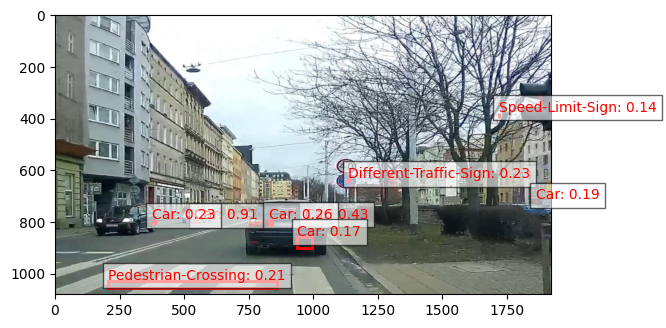

In [ ]:
class_names = ["Car", "Different-Traffic-Sign", "Green-Traffic-Light", "Motorcycle",
           "Pedestrian", "Pedestrian-Crossing", "Prohibition-Sign",
           "Red-Traffic-Light", "Speed-Limit-Sign", "Truck", "Warning-Sign"]
visualize(img, boxes, classes, scores, class_names=class_names)
